In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv(r"C:\Users\hp\Downloads\supermarket.csv\supermarket.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].dtypes)


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [7]:
print("Order Date Range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

Order Date Range:
2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [9]:
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum().reset_index()

monthly_sales["Order Date"] = monthly_sales["Order Date"].dt.to_timestamp()

monthly_sales.head()

,Order Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


In [11]:
print("Number of months:", len(monthly_sales))
print(monthly_sales.tail())

Number of months: 48
   Order Date        Sales
43 2018-08-01   62837.8480
44 2018-09-01   86152.8880
45 2018-10-01   77448.1312
46 2018-11-01  117938.1550
47 2018-12-01   83030.3888


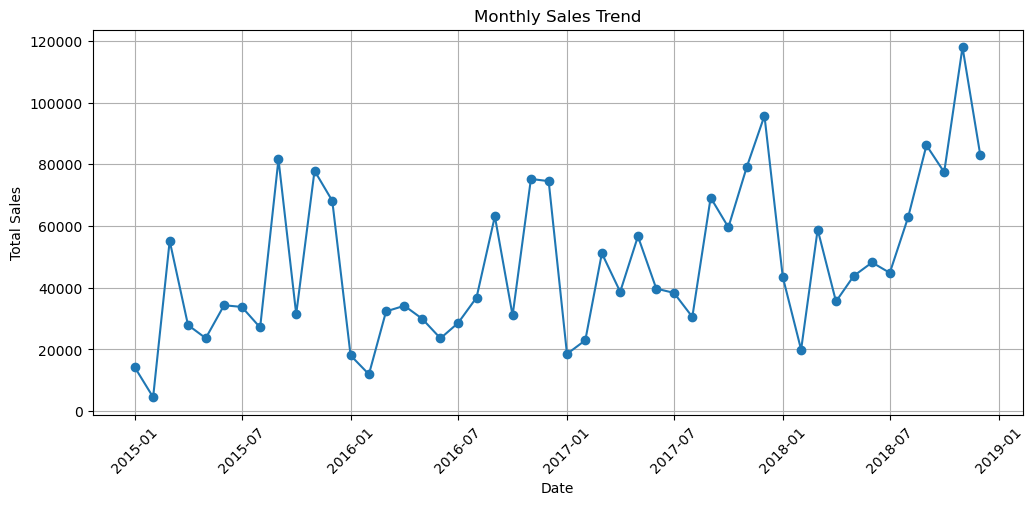

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [15]:
monthly_sales["Year"] = monthly_sales["Order Date"].dt.year
monthly_sales["Month"] = monthly_sales["Order Date"].dt.month
monthly_sales["Time_Index"] = np.arange(len(monthly_sales))

monthly_sales.head()

,Order Date,Sales,Year,Month,Time_Index
0,2015-01-01,14205.707,2015,1,0
1,2015-02-01,4519.892,2015,2,1
2,2015-03-01,55205.797,2015,3,2
3,2015-04-01,27906.855,2015,4,3
4,2015-05-01,23644.303,2015,5,4


In [19]:
monthly_sales.tail()

,Order Date,Sales,Year,Month,Time_Index
43,2018-08-01,62837.8480,2018,8,43
44,2018-09-01,86152.8880,2018,9,44
45,2018-10-01,77448.1312,2018,10,45
46,2018-11-01,117938.1550,2018,11,46
47,2018-12-01,83030.3888,2018,12,47


In [21]:
X = monthly_sales[["Year", "Month", "Time_Index"]]
y = monthly_sales["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Month  Time_Index
0  2015      1           0
1  2015      2           1
2  2015      3           2
3  2015      4           3
4  2015      5           4

Target:
0    14205.707
1     4519.892
2    55205.797
3    27906.855
4    23644.303
Name: Sales, dtype: float64


In [23]:
split_index = int(len(monthly_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 38
Testing samples: 10


In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [27]:
y_pred = model.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

prediction_results.head(10)

,Actual Sales,Predicted Sales
0,58863.4128,36768.0
1,35541.9101,41568.0
2,43825.9822,46400.0
3,48190.7277,51216.0
4,44825.1040,56032.0
5,62837.8480,60832.0
6,86152.8880,65664.0
7,77448.1312,70480.0
8,117938.1550,75280.0
9,83030.3888,80112.0


In [29]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

Model Evaluation
-----------------
MAE : 11996.71
RMSE: 17223.53
R²  : 0.486


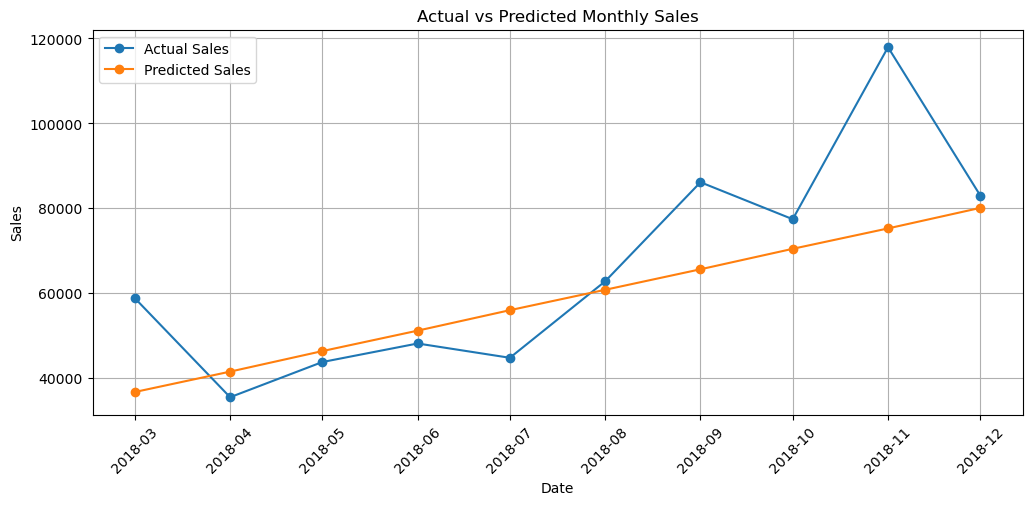

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Order Date"].iloc[split_index:],
    y_test.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Order Date"].iloc[split_index:],
    y_pred,
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [33]:
# Create dates for the next 6 months
last_date = monthly_sales["Order Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

future_data = pd.DataFrame({
    "Order Date": future_dates
})

future_data["Year"] = future_data["Order Date"].dt.year
future_data["Month"] = future_data["Order Date"].dt.month
future_data["Time_Index"] = np.arange(
    len(monthly_sales),
    len(monthly_sales) + 6
)

# Predict future sales
future_data["Predicted Sales"] = model.predict(
    future_data[["Year", "Month", "Time_Index"]]
)

future_data


,Order Date,Year,Month,Time_Index,Predicted Sales
0,2019-01-01,2019,1,48,32512.0
1,2019-02-01,2019,2,49,37344.0
2,2019-03-01,2019,3,50,42144.0
3,2019-04-01,2019,4,51,46960.0
4,2019-05-01,2019,5,52,51792.0
5,2019-06-01,2019,6,53,56592.0


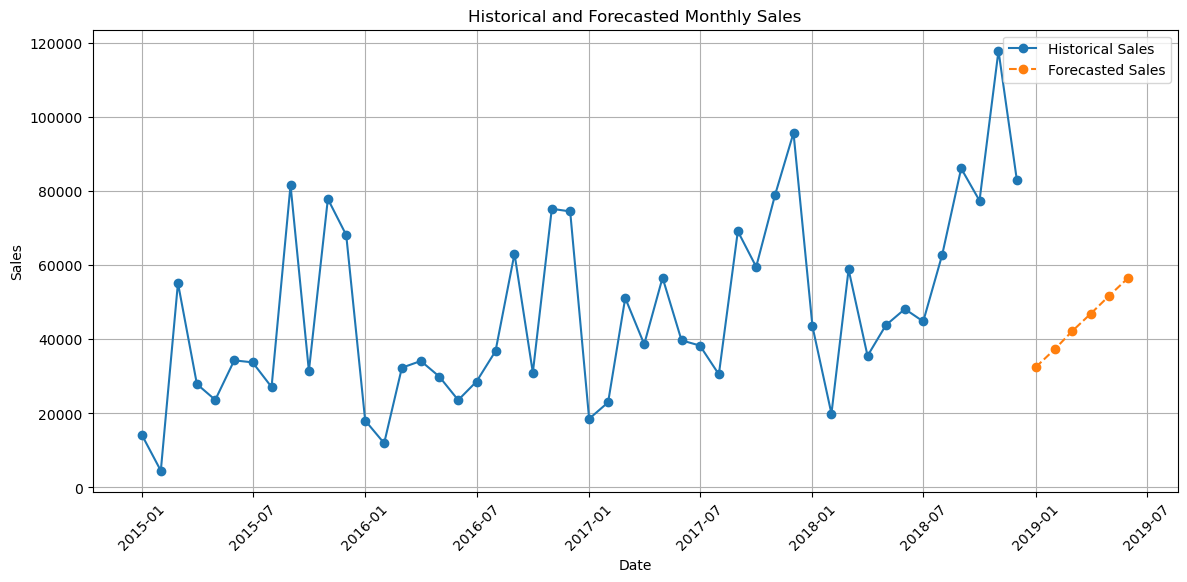

In [35]:
plt.figure(figsize=(14, 6))

# Historical sales
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

# Future predictions
plt.plot(
    future_data["Order Date"],
    future_data["Predicted Sales"],
    marker="o",
    linestyle="--",
    label="Forecasted Sales"
)

plt.title("Historical and Forecasted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()